<a href="https://colab.research.google.com/github/pietroduke/GeoIdTree/blob/main/Domain_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!unzip /content/drive/MyDrive/dora_dataset/dataset_patches_filtered/VNUF-24082024-154.zip
!unzip /content/drive/MyDrive/dora_dataset/dataset_patches_filtered/VNUF-24082024-299.zip
!unzip /content/drive/MyDrive/dora_dataset/dataset_patches_filtered/VNUF-10082024-234.zip
!unzip /content/drive/MyDrive/dora_dataset/dataset_patches_filtered/VNUF-22052024-134.zip

Streaming output truncated to the last 5000 lines.
  inflating: VNUF-24082024-299/train/Cinnamomum parthenoxylon/348_patch67.png  
  inflating: VNUF-24082024-299/train/Cinnamomum parthenoxylon/348_patch68.png  
  inflating: VNUF-24082024-299/train/Cinnamomum parthenoxylon/348_patch69.png  
  inflating: VNUF-24082024-299/train/Cinnamomum parthenoxylon/348_patch7.png  
  inflating: VNUF-24082024-299/train/Cinnamomum parthenoxylon/348_patch70.png  
  inflating: VNUF-24082024-299/train/Cinnamomum parthenoxylon/348_patch71.png  
  inflating: VNUF-24082024-299/train/Cinnamomum parthenoxylon/348_patch72.png  
  inflating: VNUF-24082024-299/train/Cinnamomum parthenoxylon/348_patch73.png  
  inflating: VNUF-24082024-299/train/Cinnamomum parthenoxylon/348_patch74.png  
  inflating: VNUF-24082024-299/train/Cinnamomum parthenoxylon/348_patch75.png  
  inflating: VNUF-24082024-299/train/Cinnamomum parthenoxylon/348_patch76.png  
  inflating: VNUF-24082024-299/train/Cinnamomum parthenoxylon/348_patc

In [26]:
# ============================================================
# CORAL Domain Adaptation — DenseNet121
# Source domain: VNUF-24082024-154 (labeled)
# Target domain: VNUF-24082024-299 / 234 / 134 (unlabeled)
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import numpy as np
import torch.nn.functional as F
import timm # Import timm library

# ─────────────────────────────────────────
# 1. CORAL LOSS — Correlation Alignment (Sun & Saenko, 2016)
# ─────────────────────────────────────────
class CORALDomainAdaptationLoss(nn.Module):
    """
    CORAL Loss — Correlation Alignment (Sun & Saenko, 2016).
    L_CORAL = (1 / 4d²) * ||C_S - C_T||²_F
    """
    def __init__(self, reduction: str = "mean"):
        super().__init__()
        assert reduction in ("mean", "sum")
        self.reduction = reduction

    @staticmethod
    def _covariance(features: torch.Tensor) -> torch.Tensor:
        """Unbiased covariance matrix (D, D). Guard cho n=1."""
        n = features.size(0)
        if n <= 1:
            d = features.size(1)
            return torch.zeros(d, d, device=features.device, dtype=features.dtype)
        features = features.float()          # AMP safety
        centered = features - features.mean(dim=0, keepdim=True)
        return (centered.T @ centered) / (n - 1)

    def forward(self, source: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        d = source.size(1)
        cov_s = self._covariance(source)
        cov_t = self._covariance(target)
        diff = cov_s - cov_t
        loss = (diff * diff).sum()
        if self.reduction == "mean":
            loss = loss / (4.0 * d * d)
        return loss


# ─────────────────────────────────────────
# 2. TRIPLET LOSS
# ─────────────────────────────────────────
class TripletLoss(nn.Module):
    """
    Triplet Loss for metric learning. Implements batch-hard mining.
    """
    def __init__(self, margin: float = 1.0):
        super().__init__()
        self.margin = margin

    def forward(self, features: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        if features.numel() == 0 or labels.numel() == 0: # Handle empty batches gracefully
            return torch.zeros(1, device=features.device)

        # Calculate pairwise squared Euclidean distances
        # (a-b)^2 = a^2 - 2ab + b^2
        dot_product = features @ features.T
        square_norm = torch.diag(dot_product)
        dist_matrix = square_norm.unsqueeze(0) - 2 * dot_product + square_norm.unsqueeze(1)
        dist_matrix = torch.sqrt(torch.relu(dist_matrix)) # Ensure non-negative and take sqrt

        loss = 0.0
        n = features.size(0)

        for i in range(n):
            anchor_label = labels[i]

            # Find positive samples (same label as anchor) excluding anchor itself
            positive_mask = (labels == anchor_label) & (torch.arange(n, device=labels.device) != i)

            # Find negative samples (different label from anchor)
            negative_mask = (labels != anchor_label)

            if not positive_mask.any() or not negative_mask.any():
                continue # Cannot form a triplet if no positives or negatives

            # Hardest positive: largest distance to anchor among positives
            hard_positive_dist = dist_matrix[i, positive_mask].max()

            # Hardest negative: smallest distance to anchor among negatives
            hard_negative_dist = dist_matrix[i, negative_mask].min()

            # Triplet loss formula
            loss += F.relu(hard_positive_dist - hard_negative_dist + self.margin)

        if n > 0:
            return loss / n
        else:
            return torch.zeros(1, device=features.device)


# ─────────────────────────────────────────
# 3. CENTER LOSS
# ─────────────────────────────────────────
class CenterLoss(nn.Module):
    """
    Center Loss for feature learning.
    Penalizes the distance between features and their corresponding class centers.
    """
    def __init__(self, num_classes: int, feat_dim: int, device: torch.device):
        super().__init__()
        self.num_classes = num_classes
        self.feat_dim = feat_dim
        self.device = device
        # Initialize centers randomly or with zeros
        self.centers = nn.Parameter(torch.randn(num_classes, feat_dim).to(device), requires_grad=False)

    def forward(self, features: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        if features.numel() == 0 or labels.numel() == 0: # Handle empty batches gracefully
            return torch.zeros(1, device=features.device)

        batch_size = features.size(0)
        # Select centers corresponding to batch labels
        batch_centers = self.centers.index_select(0, labels)
        # Calculate squared Euclidean distance
        loss = torch.sum(torch.pow(features - batch_centers, 2)) / 2.0
        return loss / batch_size

    def update_centers(self, features: torch.Tensor, labels: torch.Tensor, alpha: float):
        # Update centers for each class in the batch
        for i in range(self.num_classes):
            mask = (labels == i)
            if mask.any():
                # Move centers towards the mean of features for that class
                self.centers.data[i] -= alpha * (self.centers.data[i] - features[mask].mean(dim=0))

# ─────────────────────────────────────────
# 4. FOCAL LOSS
# ─────────────────────────────────────────
class FocalLoss(nn.Module):
    """Focal Loss for handling class imbalance"""
    def __init__(self, alpha=1, gamma=2, reduction='mean', num_classes=None):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.reduction = reduction

        if isinstance(alpha, (list, np.ndarray)):
            self.alpha = torch.tensor(alpha, dtype=torch.float)
            if num_classes is not None and len(self.alpha) != num_classes:
                raise ValueError(f"Length of alpha tensor ({len(self.alpha)}) must match num_classes ({num_classes})")
        else:
            # If alpha is a scalar, it will be applied uniformly.
            self.alpha = alpha

    def forward(self, inputs, targets):
        ce_loss = nn.CrossEntropyLoss(reduction='none')(inputs, targets)
        pt = torch.exp(-ce_loss)

        if isinstance(self.alpha, torch.Tensor):
            # Ensure alpha is on the same device as inputs
            if self.alpha.device != inputs.device:
                self.alpha = self.alpha.to(inputs.device)
            # Apply per-class alpha weighting by gathering relevant alpha for each target
            alpha_factor = self.alpha.gather(0, targets.view(-1))
        else:
            # Scalar alpha
            alpha_factor = self.alpha

        focal_loss = alpha_factor * (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss


In [27]:
# ─────────────────────────────────────────
# 2. MODEL — DenseNet121 với Feature Extractor
# ─────────────────────────────────────────
class ModelCoral(nn.Module):
    """
    DenseNet121 backbone + classifier head.
    forward() trả về (logits, features) để tính CORAL loss.
    """
    def __init__(self, num_classes: int, pretrained: bool = True):
        super().__init__()
        # Load DenseNet121 from timm, removing the default classifier head
        self.base_model = timm.create_model('densenet121', pretrained=pretrained, num_classes=0)

        # The num_features attribute from timm model will give the size after global pooling
        # For densenet121, this is 1024
        model_output_features = self.base_model.num_features

        # Bottleneck nhỏ để giảm chiều trước CORAL
        self.bottleneck = nn.Sequential(
            nn.Linear(model_output_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
        )
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x: torch.Tensor):
        # Use the base_model to get features before the classifier head
        # When num_classes=0, forward() typically returns features after global pooling
        pooled_features = self.base_model(x)  # (B, 1024)

        # If for some reason the output is not flat (e.g., (B, 1024, 1, 1)), flatten it
        if pooled_features.ndim > 2:
            pooled_features = pooled_features.flatten(1)

        feat     = self.bottleneck(pooled_features)      # (B, 256)  ← dùng cho CORAL
        logits   = self.classifier(feat)        # (B, C)
        return logits, feat                     # trả cả hai


In [28]:
# ─────────────────────────────────────────
# 3. DATA TRANSFORMS
# ─────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])




In [29]:
# ─────────────────────────────────────────
# 4. DATASET & DATALOADER
# ─────────────────────────────────────────
SOURCE_DIR = "/content/VNUF-24082024-154/train"   # labeled
TARGET_DIR = "/content/VNUF-10082024-234/train"   # unlabeled (chỉ cần ảnh)
VAL_DIR    = "/content/VNUF-24082024-154/val"

source_dataset = datasets.ImageFolder(SOURCE_DIR, transform=train_transform)
target_dataset = datasets.ImageFolder(TARGET_DIR, transform=train_transform)
val_dataset    = datasets.ImageFolder(VAL_DIR,    transform=val_transform)

NUM_CLASSES = len(source_dataset.classes)
print(f"Số lớp: {NUM_CLASSES} — {source_dataset.classes}")

source_loader = DataLoader(source_dataset, batch_size=32, shuffle=True,
                           num_workers=4, pin_memory=True, drop_last=True)
target_loader = DataLoader(target_dataset, batch_size=32, shuffle=True,
                           num_workers=4, pin_memory=True, drop_last=True)
val_loader    = DataLoader(val_dataset,    batch_size=32, shuffle=False,
                           num_workers=4, pin_memory=True)




Số lớp: 10 — ['Acacia auriculiformis', 'Alstonia scholaris', 'Aphanamixis grandifolia', 'Chukrasia tabularis', 'Cinnamomum parthenoxylon', 'Delonix regia', 'Dracontomelon dao', 'Ficus benghalensis', 'Lagerstroemia speciosa', 'Pinus massoniana']


In [30]:
# ─────────────────────────────────────────
# 5. TRAINING CONFIG
# ─────────────────────────────────────────
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS      = 50
LR          = 1e-4
CORAL_LAMBDA = 1.0   # trọng số cân bằng classification vs CORAL
TRIPLET_LAMBDA = 0.5 # trọng số cho Triplet Loss
CENTER_LAMBDA = 0.1  # trọng số cho Center Loss
CENTER_ALPHA = 0.5   # learning rate cho center update

# Focal Loss parameters
FOCAL_ALPHA = 1      # Alpha parameter for Focal Loss
FOCAL_GAMMA = 2      # Gamma parameter for Focal Loss

model      = ModelCoral(num_classes=NUM_CLASSES).to(DEVICE)
focal_loss = FocalLoss(alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA, num_classes=NUM_CLASSES).to(DEVICE) # Use Focal Loss
cora_loss = CORALDomainAdaptationLoss(reduction="mean")
triplet_loss = TripletLoss(margin=1.0) # Khởi tạo Triplet Loss
center_loss = CenterLoss(num_classes=NUM_CLASSES, feat_dim=256, device=DEVICE) # Khởi tạo Center Loss

optimizer  = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler     = torch.cuda.amp.GradScaler()   # mixed precision


/tmp/ipykernel_7916/539246216.py:20: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler     = torch.cuda.amp.GradScaler()   # mixed precision


In [31]:
# ─────────────────────────────────────────
# 6. TRAINING LOOP
# ─────────────────────────────────────────
from tqdm import tqdm # Import tqdm

def train_one_epoch(epoch: int) -> dict:
    model.train()
    target_iter = iter(target_loader)   # vòng lặp song song với source

    total_cls = total_coral = total_triplet = total_center = total_loss = correct = n = 0

    # Wrap source_loader with tqdm for a progress bar
    pbar = tqdm(source_loader, desc=f"Epoch {epoch}/{EPOCHS}")
    for src_imgs, src_labels in pbar:
        # Lấy batch target (không cần nhãn)
        try:
            tgt_imgs, _ = next(target_iter)
        except StopIteration:
            target_iter  = iter(target_loader)
            tgt_imgs, _  = next(target_iter)

        src_imgs   = src_imgs.to(DEVICE)
        src_labels = src_labels.to(DEVICE)
        tgt_imgs   = tgt_imgs.to(DEVICE)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            # Forward source → classification
            src_logits, src_feat = model(src_imgs)
            loss_cls = focal_loss(src_logits, src_labels) # Use Focal Loss for classification

            # Forward target → features (không cần nhãn)
            _, tgt_feat = model(tgt_imgs)

            # CORAL loss
            loss_coral = cora_loss(src_feat, tgt_feat)

            # Triplet Loss (using batch-hard mining)
            loss_triplet = triplet_loss(src_feat, src_labels)

            # Center Loss
            loss_center = center_loss(src_feat, src_labels)

            # Tổng loss
            loss = loss_cls + CORAL_LAMBDA * loss_coral + TRIPLET_LAMBDA * loss_triplet + CENTER_LAMBDA * loss_center

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Update centers for Center Loss (outside scaler update and backprop for model)
        # Detach features to prevent backprop through feature extractor during center update
        center_loss.update_centers(src_feat.detach(), src_labels, CENTER_ALPHA)

        # Thống kê
        bs = src_imgs.size(0)
        total_cls   += loss_cls.item()   * bs
        total_coral += loss_coral.item() * bs
        total_triplet += loss_triplet.item() * bs
        total_center  += loss_center.item()  * bs
        total_loss  += loss.item()       * bs
        correct     += (src_logits.argmax(1) == src_labels).sum().item()
        n           += bs

        # Update tqdm progress bar description
        pbar.set_postfix({
            'L_cls': f'{loss_cls.item():.4f}',
            'L_coral': f'{loss_coral.item():.4f}',
            'L_triplet': f'{loss_triplet.item():.4f}',
            'L_center': f'{loss_center.item():.4f}',
            'L_total': f'{loss.item():.4f}',
            'Acc_src': f'{(correct/n)*100:.1f}%'
        })

    scheduler.step()
    return {
        "loss_cls":   total_cls   / n,
        "loss_coral": total_coral / n,
        "loss_triplet": total_triplet / n,
        "loss_center":  total_center  / n,
        "loss_total": total_loss  / n,
        "acc_src":    correct     / n,
    }


@torch.no_grad()
def evaluate(loader: DataLoader) -> dict:
    model.eval()
    correct = n = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits, _ = model(imgs)
        correct += (logits.argmax(1) == labels).sum().item()
        n       += imgs.size(0)
    return {"acc": correct / n}


In [33]:
# ─────────────────────────────────────────
# 7. MAIN LOOP
# ─────────────────────────────────────────
best_val_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    train_stats = train_one_epoch(epoch)
    val_stats   = evaluate(val_loader)

    print(
        f"Epoch {epoch:3d}/{EPOCHS} | "
        f"L_cls={train_stats['loss_cls']:.4f}  "
        f"L_coral={train_stats['loss_coral']:.4f}  "
        f"L_triplet={train_stats['loss_triplet']:.4f}  " \
        f"L_center={train_stats['loss_center']:.4f}  " \
        f"L_total={train_stats['loss_total']:.4f} | "
        f"Acc_src={train_stats['acc_src']*100:.1f}%  "
        f"Acc_val={val_stats['acc']*100:.1f}%"
    )

    # Lưu checkpoint tốt nhất
    if val_stats["acc"] > best_val_acc:
        best_val_acc = val_stats["acc"]
        torch.save({
            "epoch":      epoch,
            "model":      model.state_dict(),
            "optimizer":  optimizer.state_dict(),
            "val_acc":    best_val_acc,
        }, "/content/drive/MyDrive/dora_dataset/best_coral_model.pth")
        print(f"   ✅ Saved best model — val_acc={best_val_acc*100:.1f}%")

print(f"\nBest val acc: {best_val_acc*100:.2f}%")


Epoch 1/50:   0%|          | 0/527 [00:00<?, ?it/s]/tmp/ipykernel_7916/795736522.py:28: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/50: 100%|██████████| 527/527 [02:06<00:00,  4.16it/s, L_cls=0.4451, L_coral=0.0004, L_triplet=0.6177, L_center=5.7121, L_total=1.3256, Acc_src=77.0%]


Epoch   1/50 | L_cls=0.8266  L_coral=0.0012  L_triplet=1.4065  L_center=15.6985  L_total=3.1009 | Acc_src=77.0%  Acc_val=77.4%
   ✅ Saved best model — val_acc=77.4%


Epoch 2/50: 100%|██████████| 527/527 [02:07<00:00,  4.15it/s, L_cls=0.3000, L_coral=0.0004, L_triplet=0.2690, L_center=4.5289, L_total=0.8878, Acc_src=88.9%]


Epoch   2/50 | L_cls=0.3945  L_coral=0.0006  L_triplet=0.7460  L_center=5.5918  L_total=1.3273 | Acc_src=88.9%  Acc_val=79.5%
   ✅ Saved best model — val_acc=79.5%


Epoch 3/50: 100%|██████████| 527/527 [02:06<00:00,  4.16it/s, L_cls=0.5493, L_coral=0.0003, L_triplet=1.5684, L_center=4.8509, L_total=1.8189, Acc_src=91.4%]


Epoch   3/50 | L_cls=0.2893  L_coral=0.0004  L_triplet=0.5711  L_center=3.7777  L_total=0.9530 | Acc_src=91.4%  Acc_val=80.2%
   ✅ Saved best model — val_acc=80.2%


Epoch 4/50:  12%|█▏        | 63/527 [00:15<01:56,  3.98it/s, L_cls=0.2607, L_coral=0.0003, L_triplet=0.2305, L_center=1.9464, L_total=0.5708, Acc_src=92.9%]


KeyboardInterrupt: 

### Đánh giá cuối cùng trên tập kiểm tra
Sau khi quá trình huấn luyện hoàn tất, chúng ta sẽ tải mô hình tốt nhất đã lưu và đánh giá hiệu suất của nó trên tập dữ liệu kiểm tra riêng biệt.

Số mẫu test: 788

─────────────────────────────────────────
8. FINAL EVALUATION ON TEST SET
─────────────────────────────────────────
Loaded best model from epoch 3 with val_acc=80.16%
Final Test Accuracy: 78.93%

─────────────────────────────────────────
Confusion Matrix
─────────────────────────────────────────
[[138   0   0   0   0   1   0   0   0   0]
 [  0   3   1   0   2   0   1   1   0   0]
 [  1   0  72   2   3   0   9   0   0   0]
 [  0   0   0  88   1   0   5   0   0   1]
 [  3   0   2   1  31   0  28   1   0   0]
 [  0   0   0   0   0  29   0   0   0   0]
 [  0   0   2   0   5   0  61   0   0   0]
 [  1   0   0   0  16   0   0   0   0   0]
 [  0   0   3  56   3   0   0   8  12   0]
 [  9   0   0   0   0   0   0   0   0 188]]


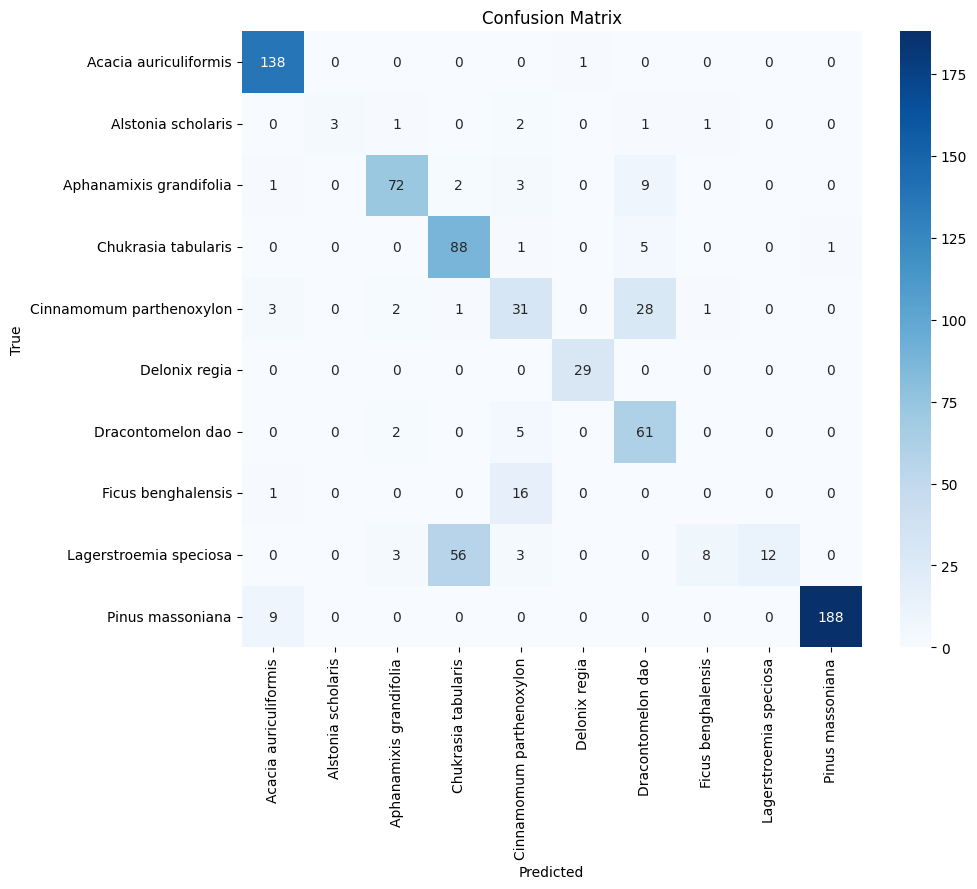


─────────────────────────────────────────
Classification Report
─────────────────────────────────────────
                          precision    recall  f1-score   support

   Acacia auriculiformis       0.91      0.99      0.95       139
      Alstonia scholaris       1.00      0.38      0.55         8
 Aphanamixis grandifolia       0.90      0.83      0.86        87
     Chukrasia tabularis       0.60      0.93      0.73        95
Cinnamomum parthenoxylon       0.51      0.47      0.49        66
           Delonix regia       0.97      1.00      0.98        29
       Dracontomelon dao       0.59      0.90      0.71        68
      Ficus benghalensis       0.00      0.00      0.00        17
  Lagerstroemia speciosa       1.00      0.15      0.26        82
        Pinus massoniana       0.99      0.95      0.97       197

                accuracy                           0.79       788
               macro avg       0.75      0.66      0.65       788
            weighted avg       0.

In [37]:
TEST_DIR   = "/content/VNUF-24082024-154/test" # Dedicated test set
test_dataset   = datasets.ImageFolder(TEST_DIR,   transform=val_transform)
test_loader   = DataLoader(test_dataset,   batch_size=32, shuffle=False,
                           num_workers=4, pin_memory=True)
print(f"Số mẫu test: {len(test_dataset)}")
# ─────────────────────────────────────────
# 8. FINAL EVALUATION ON TEST SET
# ─────────────────────────────────────────
print("\n─────────────────────────────────────────")
print("8. FINAL EVALUATION ON TEST SET")
print("─────────────────────────────────────────")

# Khởi tạo mô hình mới để tải trọng số
# Đảm bảo NUM_CLASSES, DEVICE đã được định nghĩa từ các cell trước
model_test = ModelCoral(num_classes=NUM_CLASSES).to(DEVICE)

# Load the best model
best_model_path = "/content/drive/MyDrive/dora_dataset/best_coral_model.pth"
checkpoint = torch.load(best_model_path, map_location=DEVICE)
model_test.load_state_dict(checkpoint["model"])
print(f"Loaded best model from epoch {checkpoint['epoch']} with val_acc={checkpoint['val_acc']*100:.2f}%")

# Evaluate on test set
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

@torch.no_grad()
def evaluate_and_predict(model_to_eval, loader: DataLoader):
    model_to_eval.eval()
    all_preds = []
    all_labels = []
    correct = n = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits, _ = model_to_eval(imgs)
        predictions = logits.argmax(1)

        correct += (predictions == labels).sum().item()
        n       += imgs.size(0)

        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return {"acc": correct / n, "predictions": all_preds, "labels": all_labels}


test_results = evaluate_and_predict(model_test, test_loader)
test_acc = test_results["acc"]
all_preds = test_results["predictions"]
all_labels = test_results["labels"]

print(f"Final Test Accuracy: {test_acc*100:.2f}%")

# Generate Confusion Matrix
print("\n─────────────────────────────────────────")
print("Confusion Matrix")
print("─────────────────────────────────────────")
cm = confusion_matrix(all_labels, all_preds)
print(cm)

# Visualize Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_dataset.classes, yticklabels=test_dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Generate Classification Report
print("\n─────────────────────────────────────────")
print("Classification Report")
print("─────────────────────────────────────────")
report = classification_report(all_labels, all_preds, target_names=test_dataset.classes)
print(report)


### Tạo folder mới và trộn dữ liệu

In [16]:
import os
import shutil

# Define base paths for the source dataset
SOURCE_BASE_DIR = "/content/VNUF-10082024-234"
SOURCE_TRAIN_DIR = os.path.join(SOURCE_BASE_DIR, "train")
SOURCE_VAL_DIR = os.path.join(SOURCE_BASE_DIR, "val")
SOURCE_TEST_DIR = os.path.join(SOURCE_BASE_DIR, "test")

# Define the destination path for the mixed dataset
DEST_MIX_DIR = "/content/VNUF-10082024-234-mix"

print(f"Source dataset base directory: {SOURCE_BASE_DIR}")
print(f"Destination mixed directory: {DEST_MIX_DIR}")

Source dataset base directory: /content/VNUF-10082024-234
Destination mixed directory: /content/VNUF-10082024-234-mix


In [17]:
# Create the destination mixed directory if it doesn't exist
os.makedirs(DEST_MIX_DIR, exist_ok=True)
print(f"Created or ensured existence of: {DEST_MIX_DIR}")

# List of source directories to combine
source_dirs = [SOURCE_TRAIN_DIR, SOURCE_VAL_DIR, SOURCE_TEST_DIR]

# Iterate through each source directory (train, val, test)
for src_root_dir in source_dirs:
    if not os.path.exists(src_root_dir):
        print(f"Warning: Source directory not found: {src_root_dir}. Skipping.")
        continue

    print(f"\nProcessing images from: {src_root_dir}")
    # Iterate through each class subfolder in the current source directory
    for class_name in os.listdir(src_root_dir):
        src_class_dir = os.path.join(src_root_dir, class_name)
        dest_class_dir = os.path.join(DEST_MIX_DIR, class_name)

        # Create the corresponding class subfolder in the destination mixed directory
        os.makedirs(dest_class_dir, exist_ok=True)

        # Copy all image files from the source class directory to the destination class directory
        for filename in os.listdir(src_class_dir):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.gif')):
                src_file_path = os.path.join(src_class_dir, filename)
                dest_file_path = os.path.join(dest_class_dir, filename)

                # Handle potential duplicate filenames by appending a suffix
                counter = 1
                original_filename_no_ext, ext = os.path.splitext(filename)
                while os.path.exists(dest_file_path):
                    dest_file_path = os.path.join(dest_class_dir, f"{original_filename_no_ext}_{counter}{ext}")
                    counter += 1

                shutil.copy(src_file_path, dest_file_path)

        print(f"  Copied images for class '{class_name}' to {dest_class_dir}")

print("\n✨ Data mixing complete. All images are now in the VNUF-24082024-299-mix folder.")

Created or ensured existence of: /content/VNUF-10082024-234-mix

Processing images from: /content/VNUF-10082024-234/train
  Copied images for class 'Lagerstroemia speciosa' to /content/VNUF-10082024-234-mix/Lagerstroemia speciosa
  Copied images for class 'Delonix regia' to /content/VNUF-10082024-234-mix/Delonix regia
  Copied images for class 'Cinnamomum parthenoxylon' to /content/VNUF-10082024-234-mix/Cinnamomum parthenoxylon
  Copied images for class 'Acacia auriculiformis' to /content/VNUF-10082024-234-mix/Acacia auriculiformis
  Copied images for class 'Ficus benghalensis' to /content/VNUF-10082024-234-mix/Ficus benghalensis
  Copied images for class 'Dracontomelon dao' to /content/VNUF-10082024-234-mix/Dracontomelon dao
  Copied images for class 'Aphanamixis grandifolia' to /content/VNUF-10082024-234-mix/Aphanamixis grandifolia
  Copied images for class 'Chukrasia tabularis' to /content/VNUF-10082024-234-mix/Chukrasia tabularis
  Copied images for class 'Alstonia scholaris' to /c